# Answers to hw 1 coding questions

**Question 4, part c**

In [70]:
import numpy as np
import matplotlib.pyplot as plt

In [47]:
def func(t,I0):
    const = 1*I0*2/(2-10)
    exp = np.exp(-t/2)-np.exp(-t/10)
    return const*exp

In [74]:
I0 = 5
#after experimenting, changing I0 doesn't change where the peak occurs
tpeak = 10*2*np.log(2/10)/(2-10)
r = 2/10
umax = 1*I0*(r)**(-1/(r-1))

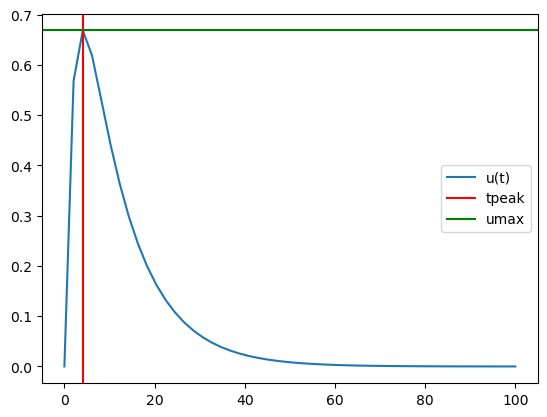

In [140]:
t_list = np.linspace(0,100)

plt.plot(t_list,func(t_list,I0),label='u(t)')
plt.axvline(tpeak,color='red',label = 'tpeak')
plt.axhline(umax,color='green',label = 'umax')
plt.legend()
plt.show()

In [129]:
I0crit = 1*r**(1/(r-1))/1
I02 = I0crit/2
I032 = 3*I0crit/2
#I0crit and tpeak is the same across different I0s because they only rely on Ts,Tm,R, and uth

umax2 = 1*I02*(r)**(-1/(r-1))
umaxcrit = 1*I0crit*(r)**(-1/(r-1))
umax32 = 1*I032*(r)**(-1/(r-1))
umax2

0.5

In [131]:
umaxcrit

1.0

In [123]:
umax32

1.5

In [127]:
umax

0.668740304976422

In [97]:
tpeak

4.023594781085251

In [99]:
I0crit

7.476743906106102

|  | I0crit/2 | I0crit | 3I0crit/2 |
|----------|----------|----------|----------|
| tpeak    | 4.024     | 4.024     | 4.024     |
| I0crit    | 7.477     | 7.477     | 7.477     |
| umax    | 0.5     | 1     | 1.5     |

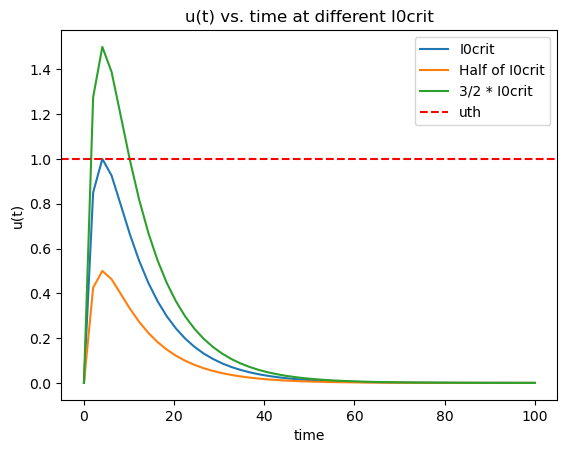

In [117]:
plt.plot(t_list,func(t_list,I0crit),label ='I0crit')
plt.plot(t_list,func(t_list,I0crit/2),label ='Half of I0crit')
plt.plot(t_list,func(t_list,3*I0crit/2),label ='3/2 * I0crit')
plt.axhline(1,label = 'uth',color = 'red',linestyle = '--')
plt.ylabel('u(t)')
plt.xlabel('time')
plt.title('u(t) vs. time at different I0crit')
plt.legend()
plt.show()

The limit of u(t) with the different I0 is that they all approach 0 as time goes to infinity. This is because the neuron will eventually stop firing on it's own without additional input, even if it does cross the threshold or have several spikes.

In [144]:
taus = np.linspace(0.5e-3,100e-3)

def I0crit(taus):
    r = taus/10
    return 1*r**(1/(r-1))/1

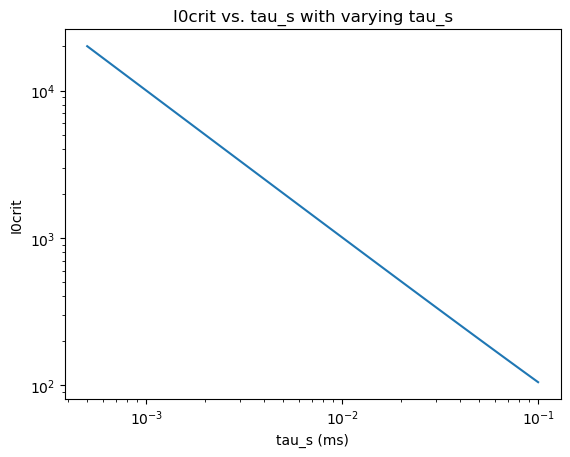

In [166]:
plt.loglog(taus,I0crit(taus))
plt.xlabel('tau_s (ms)')
plt.ylabel('I0crit')
plt.title('I0crit vs. tau_s with varying tau_s')
plt.show()

The limit of I0crit as tau_s gets larger is uth/R, which for these parameters is 1. uth/R is also what I0crit is. As Ts goes to 0, the I0crit goes to infinite because the neuron must have a lot of current to have a quick spike (i.e. a short timescale).

**Question 5, part a**

In [191]:
import hh_sim as hh

Sustained firing occurs at Id = 7 and produces 11 spikes. Repetitive sustained firing is defined as just below 50% of the way to this level of sustained firing, so that is 6 spikes. A current is considered to be enough to cause repetiive sustained firing if it causes at least 6 spikes. Skipfrac was kept the same at 40%.

In [345]:
def is_rep(I):
    t, V, spk, rate = hh.hh_sim(I)
    return len(spk) >=6

In [250]:
tol = 1e-6
I_h = 7
I_l = 6

while abs(I_h - I_l) > tol:

    mid = (I_l + I_h) / 2
    if is_rep(mid):
        I_h = mid
    else:
        I_l = mid

In [335]:
I_rheo = (I_l + I_h) / 2
I_rheo

6.260440349578857

In [337]:
I_rheo =round(I_rheo,3)
I_rheo

6.26

In [339]:
tb, Vb, spkb, rateb = hh.hh_sim(I_rheo-0.001)
ta, Va, spka, ratea = hh.hh_sim(I_rheo+0.001)

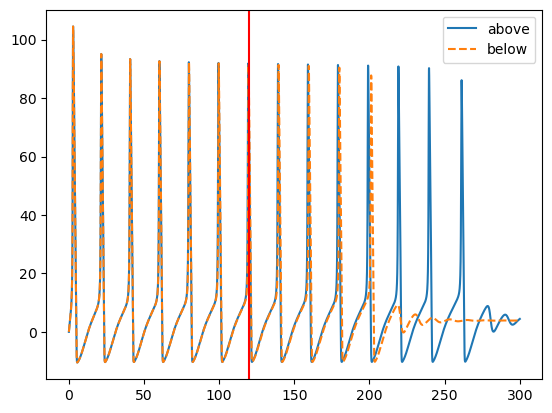

In [343]:
plt.plot(ta,Va,label = 'above')
plt.plot(tb,Vb,label = 'below',linestyle='--')
plt.axvline(120,color='red')
plt.legend()
plt.show()

The spikes in the first 120 ms are ignored because the skipfrac is 40%. 40% of 300 ms (tmax) is 120 ms.

**Question 5, part b**

Compute the firing rate at a sequence of currents from just above rheobase up to roughly twice it, plot
the f–I curve, and report the onset rate to three digits. Does the rate rise continuously from zero, or switch
on at a nonzero value? Which of the two bifurcation scenarios from problems 2 and 3 does Hodgkin-Huxley
resemble, and what is the physiological consequence?

In [321]:
curr_seq = np.linspace(I_rheo,2*I_rheo)
curr_seq

array([ 6.258     ,  6.38571429,  6.51342857,  6.64114286,  6.76885714,
        6.89657143,  7.02428571,  7.152     ,  7.27971429,  7.40742857,
        7.53514286,  7.66285714,  7.79057143,  7.91828571,  8.046     ,
        8.17371429,  8.30142857,  8.42914286,  8.55685714,  8.68457143,
        8.81228571,  8.94      ,  9.06771429,  9.19542857,  9.32314286,
        9.45085714,  9.57857143,  9.70628571,  9.834     ,  9.96171429,
       10.08942857, 10.21714286, 10.34485714, 10.47257143, 10.60028571,
       10.728     , 10.85571429, 10.98342857, 11.11114286, 11.23885714,
       11.36657143, 11.49428571, 11.622     , 11.74971429, 11.87742857,
       12.00514286, 12.13285714, 12.26057143, 12.38828571, 12.516     ])

In [324]:
rate_list = []
for c in curr_seq:
    t, V, spk, rate = hh.hh_sim(c)
    rate_list.append(rate)

rate_arr = np.array(rate_list)

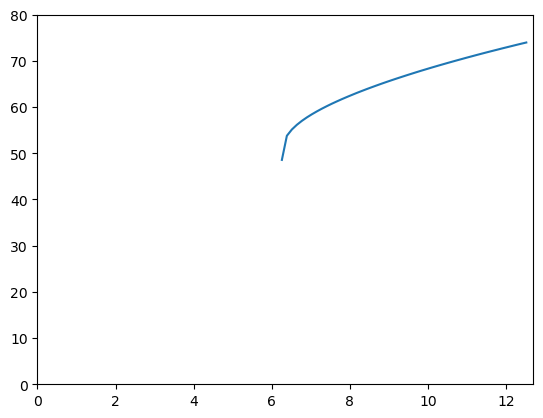

In [352]:
plt.plot(curr_seq,rate_arr)
plt.xlim(0, 12.70)
plt.ylim(0, 80)
plt.show()

In [350]:
onset_rate = rate_arr[0]
onset_rate

48.56726566294317

The rate switches on at a nonzero value, and this represents the FitzHugh-Nagumo model (question 2). The physiological consequence is that it suggests that neurons won't fire at all unless there is some mimumum level of input provided.

**Question 5, part c**

Change gK from 36 to 30 (mS/cm2) and recompute the rheobase by the same bisection. Report both
rheobase values to three digits in a small table, and overlay the two f–I curves on a single set of axes with
the two rheobase values marked. Did the rheobase go up or down? Explain the result in terms of the currents
in the model, and say whether the shape of the curve changed or only its position

In [362]:
def is_rep_30(I):
    t, V, spk, rate = hh.hh_sim(I,gK=30)
    return len(spk) >=6

In [364]:
tol = 1e-6
I_h30 = 7
I_l30 = 6

while abs(I_h30 - I_l30) > tol:

    mid30 = (I_l30 + I_h30) / 2
    if is_rep_30(mid30):
        I_h30 = mid30
    else:
        I_l30 = mid30

In [374]:
I_rheo30 = (I_l30 + I_h30) / 2
I_rheo30

6.000000476837158

In [376]:
I_rheo30 = round(I_rheo30,3)
I_rheo30

6.0

|  | I_rheo | I_rheo30 |
|----------|----------|----------|
|     | 6.260     | 6.000     |

In [380]:
curr_seq30 = np.linspace(I_rheo30,2*I_rheo30)

rate_list30 = []
for c in curr_seq30:
    t, V, spk, rate = hh.hh_sim(c)
    rate_list30.append(rate)

rate_arr30 = np.array(rate_list30)

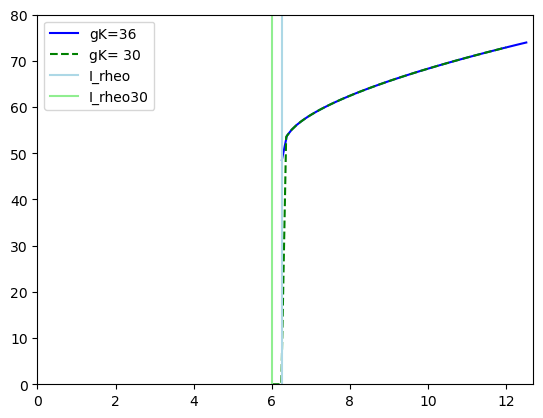

In [396]:
plt.plot(curr_seq,rate_arr,label = 'gK=36',color='blue')
plt.plot(curr_seq30,rate_arr30,label='gK= 30',color='green',linestyle='--')
plt.axvline(6.260,color='lightblue',label='I_rheo')
plt.axvline(6.000,color= 'lightgreen',label='I_rheo30')
plt.xlim(0, 12.70)
plt.ylim(0, 80)
plt.legend()
plt.show()

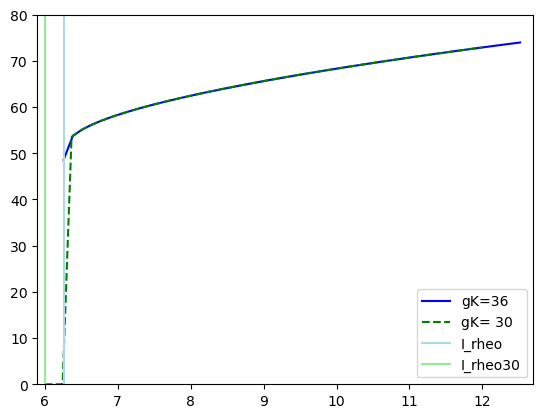

In [392]:
plt.plot(curr_seq,rate_arr,label = 'gK=36',color='blue')
plt.plot(curr_seq30,rate_arr30,label='gK= 30',color='green',linestyle='--')
plt.axvline(6.260,color='lightblue',label='I_rheo')
plt.axvline(6.000,color= 'lightgreen',label='I_rheo30')
plt.xlim(5.9, 12.70)
plt.ylim(0, 80)
plt.legend()
plt.show()

The rheobase went down as gK went down. When gK decreases, the maximal conductance of potassium is decreased, so the neuron is less negative at its resting value. This makes it need less current/positive voltage to fire. This is why I_rheo30 is less than I_rheo. The shape of the curve to the right is the same, but the gK=30 curve decreases gradually to around I_rheo and then goes to 0 for the same reason. The shape of the curve changed. It can be seen that the critical curent is the same on both curves because the value the neuron needs to fire won't change based on the max potassium conductance.